In [1]:
# Install necessary libraries: torch, torchvision, torchaudio, opencv-python, matplotlib, and albumentations.
# torch, torchvision, and torchaudio are installed with CUDA support for GPU acceleration.
# opencv-python is used for image processing.
# matplotlib is used for plotting and visualization.
# albumentations is used for data augmentation.
!pip -q install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install opencv-python matplotlib albumentations==1.3.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 12.8 MB/s eta 0:00:00


In [2]:
# ===========================================
# Mask R-CNN in Google Colab - End to End
# Penn-Fudan Pedestrian instance segmentation
# ===========================================

# Import necessary libraries
import os
import torch
import torchvision
import numpy as np
import cv2
import random
import time
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from typing import Tuple, Dict, List
import albumentations as A

# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__, "Torchvision:", torchvision.__version__)

Device: cuda
Torch: 2.11.0+cu128 Torchvision: 0.26.0+cu128


In [3]:
# ===========================
# Download and unpack dataset
# ===========================
# Penn-Fudan Ped - pedestrians with per-instance masks
# https://www.cis.upenn.edu/~jshi/ped_html/

# Create a data directory if it doesn't exist
data_root = Path("data")
data_root.mkdir(parents=True, exist_ok=True)

# Download and unzip the dataset if it's not already present
if not (data_root / "PennFudanPed").exists():
    !wget -q https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -O {data_root/"PennFudanPed.zip"}
    !unzip -q {data_root/"PennFudanPed.zip"} -d {data_root}
else:
    print("Dataset already present")

# Define the path to the dataset directory
dataset_dir = data_root / "PennFudanPed"
print("Dataset path:", dataset_dir)

Dataset path: data/PennFudanPed


In [4]:
# ===========================================
# Dataset class with masks and target dicts
# ===========================================
# This closely follows the torchvision tutorial, but is self contained and
# uses Albumentations for simple augmentations.

# Define the dataset class for Penn-Fudan Pedestrian
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root: Path, transforms=None):
        self.root = Path(root)
        # Get list of image and mask files, sorted for consistency
        self.imgs = sorted((self.root / "PNGImages").glob("*.png"))
        self.masks = sorted((self.root / "PedMasks").glob("*.png"))
        self.transforms = transforms

    def __len__(self) -> int:
        # Return the total number of samples in the dataset
        return len(self.imgs)

    def __getitem__(self, idx: int):
        # Get the image and mask paths for the given index
        img_path = self.imgs[idx]
        mask_path = self.masks[idx]

        # Open image and mask, convert image to RGB and mask to numpy array
        img = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        # Instances are encoded as different colors in the mask
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[1:]  # first id is background (0)

        # Create a binary mask for each instance
        masks = mask == obj_ids[:, None, None]

        # Get bounding boxes from masks
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            ymin = np.min(pos[0])
            xmin = np.min(pos[1])
            ymax = np.max(pos[0])
            xmax = np.max(pos[1])
            boxes.append([xmin, ymin, xmax, ymax])
        boxes = np.array(boxes, dtype=np.float32)

        # Labels: 1 for person (as per dataset)
        labels = np.ones((num_objs,), dtype=np.int64)

        # Convert masks to uint8
        masks = masks.astype(np.uint8)

        # Apply Albumentations transforms if provided
        if self.transforms:
            transformed = self.transforms(
                image=img,
                masks=[m for m in masks],
                bboxes=[(*box, 0) for box in boxes],  # dummy label for bbox
            )
            img = transformed["image"]
            masks = transformed["masks"]
            boxes = np.array([b[:4] for b in transformed["bboxes"]], dtype=np.float32)
        else:
            img = img

        # Convert image and masks to PyTorch tensors
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        masks = torch.from_numpy(np.stack(masks, axis=0)).type(torch.uint8)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Assume no crowd instances for this dataset
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Create the target dictionary in the required format for torchvision models
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": iscrowd,
        }
        return img, target

# Simple augmentations for train and identity for val using Albumentations
def get_train_transforms(img_size=800):
    # Define training transformations
    return A.Compose(
        [
            A.LongestMaxSize(max_size=img_size, interpolation=cv2.INTER_LINEAR), # Resize the longest side to img_size
            A.PadIfNeeded(min_height=img_size, min_width=img_size, border_mode=cv2.BORDER_CONSTANT, value=0), # Pad to img_size x img_size
            A.HorizontalFlip(p=0.5), # Random horizontal flip
            A.ColorJitter(p=0.3, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Random color jitter
        ],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=[]), # Bbox parameters
    )

def get_val_transforms(img_size=800):
    # Define validation transformations (only resizing and padding)
    return A.Compose(
        [
            A.LongestMaxSize(max_size=img_size, interpolation=cv2.INTER_LINEAR),
            A.PadIfNeeded(min_height=img_size, min_width=img_size, border_mode=cv2.BORDER_CONSTANT, value=0),
        ],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=[]),
    )

# Split train-val indices deterministically
all_images = sorted((dataset_dir / "PNGImages").glob("*.png"))
indices = list(range(len(all_images)))
random.seed(42) # Set random seed for reproducibility
random.shuffle(indices)
val_count = max(1, int(0.2 * len(indices))) # 20% for validation, at least 1
val_indices = set(indices[:val_count])

# Create dataset instances with respective transforms
train_ds = PennFudanDataset(dataset_dir, transforms=get_train_transforms())
val_ds = PennFudanDataset(dataset_dir, transforms=get_val_transforms())

# Subset wrappers to ensure deterministic split
# This class creates a subset of the base dataset based on provided indices.
class SubsetDet(torch.utils.data.Dataset):
    def __init__(self, base_ds, keep_set):
        self.base = base_ds
        self.keep = sorted(list(keep_set))
        self.map = []
        img_names = sorted((dataset_dir / "PNGImages").glob("*.png"))
        name_to_idx = {p.name: i for i, p in enumerate(img_names)}
        for k in self.keep:
            self.map.append(k)
    def __len__(self):
        return len(self.map)
    def __getitem__(self, i):
        # Return item from the base dataset using the mapped index
        return self.base[self.map[i]]

# Determine the indices for training and validation subsets
train_keep = set([i for i in range(len(all_images)) if i not in val_indices])
val_keep = val_indices

# Create the final training and validation datasets using the SubsetDet wrapper
train_dataset = SubsetDet(train_ds, train_keep)
val_dataset = SubsetDet(val_ds, val_keep)

# Define a collate function to handle batching of data with varying number of objects
def collate_fn(batch):
    return tuple(zip(*batch))

# Create data loaders for training and validation
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_fn
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn
)

# Print the size of the training and validation datasets
len(train_dataset), len(val_dataset)

(136, 34)

In [5]:
# =======================================
# Build Mask R-CNN and replace the heads
# =======================================
# Import necessary modules for building the Mask R-CNN model
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# Define a function to get the Mask R-CNN model with a custom head
def get_model_instance_segmentation(num_classes: int = 2):
    # Load a pre-trained Mask R-CNN model with a ResNet50-FPN backbone
    # 2 classes for Penn-Fudan: 1 background + 1 person
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Replace the pre-trained box predictor with a new one that has the number of classes we need
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Replace the pre-trained mask predictor with a new one
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden = 256 # Hidden layer size for the mask predictor
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden, num_classes)
    return model

# Get the model and move it to the specified device (GPU or CPU)
model = get_model_instance_segmentation(num_classes=2).to(device)

# Optimizer and scheduler
# Get parameters that require gradients for optimization
params = [p for p in model.parameters() if p.requires_grad]
# Define the optimizer (Stochastic Gradient Descent)
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
# Define the learning rate scheduler (step decay)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 189MB/s]


In [6]:
# ============================
# Training and simple eval loop
# ============================

# Define the training function for one epoch
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=20):
    model.train() # Set the model to training mode
    # Initialize dictionary to store running loss values
    running = {"loss": 0.0, "loss_classifier": 0.0, "loss_box_reg": 0.0,
               "loss_mask": 0.0, "loss_objectness": 0.0, "loss_rpn_box_reg": 0.0}
    count = 0
    start = time.time() # Start time for epoch duration calculation
    # Iterate over the data loader
    for i, (images, targets) in enumerate(data_loader):
        # Move images and targets to the specified device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass: compute the loss dictionary
        loss_dict = model(images, targets)
        # Sum up all the losses
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass and optimization
        optimizer.zero_grad() # Clear previous gradients
        losses.backward() # Compute gradients
        optimizer.step() # Update model parameters

        # Update running loss values
        for k in running.keys():
            if k in loss_dict:
                running[k] += loss_dict[k].item()
        running["loss"] += losses.item()
        count += 1

        # Print training progress at specified frequency
        if (i + 1) % print_freq == 0 or (i + 1) == len(data_loader):
            avg_loss = running["loss"] / count
            print(f"Epoch {epoch} - Iter {i+1}/{len(data_loader)} - avg_loss {avg_loss:.4f}")

    # Calculate and print epoch summary
    elapsed = time.time() - start
    for k in running:
        running[k] = running[k] / max(1, count) # Avoid division by zero
    print(f"Epoch {epoch} summary - {running} - time {elapsed:.1f}s")
    return running

# Define a simple evaluation function using validation loss
@torch.no_grad() # Disable gradient calculation for evaluation
def evaluate_on_val_loss(model, data_loader, device):
    # Mask R-CNN returns losses only in train mode, so we temporarily enable train mode but skip backward
    model.train()
    totals = {"loss": 0.0}
    n = 0
    # Iterate over the validation data loader
    for images, targets in data_loader:
        # Move images and targets to the specified device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        # Forward pass: compute the loss dictionary
        loss_dict = model(images, targets)
        # Sum up all the losses
        losses = sum(loss for loss in loss_dict.values())
        # Accumulate total loss
        totals["loss"] += losses.item()
        n += 1
    # Calculate average validation loss
    totals = {k: v / max(1, n) for k, v in totals.items()}
    print(f"Validation proxy loss: {totals['loss']:.4f}")
    return totals

# Training loop
num_epochs = 5 # Number of training epochs
for epoch in range(1, num_epochs + 1):
    # Train for one epoch and get training statistics
    train_stats = train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=10)
    # Step the learning rate scheduler
    lr_scheduler.step()
    # Evaluate on the validation set using validation loss
    _ = evaluate_on_val_loss(model, val_loader, device)

# Save checkpoint
ckpt_path = "maskrcnn_pennfudan.pth" # Path to save the model checkpoint
torch.save(model.state_dict(), ckpt_path) # Save the model's state dictionary
print("Saved model to", ckpt_path)

Epoch 1 - Iter 10/68 - avg_loss 1.3915
Epoch 1 - Iter 20/68 - avg_loss 0.9924
Epoch 1 - Iter 30/68 - avg_loss 0.8299
Epoch 1 - Iter 40/68 - avg_loss 0.7186
Epoch 1 - Iter 50/68 - avg_loss 0.6381
Epoch 1 - Iter 60/68 - avg_loss 0.5861
Epoch 1 - Iter 68/68 - avg_loss 0.5516
Epoch 1 summary - {'loss': 0.5516059716396472, 'loss_classifier': 0.08642625948414207, 'loss_box_reg': 0.16415303737363396, 'loss_mask': 0.2848319748745245, 'loss_objectness': 0.009205710946095196, 'loss_rpn_box_reg': 0.006988982808680329} - time 32.5s
Validation proxy loss: 0.2806
Epoch 2 - Iter 10/68 - avg_loss 0.2581
Epoch 2 - Iter 20/68 - avg_loss 0.2661
Epoch 2 - Iter 30/68 - avg_loss 0.2618
Epoch 2 - Iter 40/68 - avg_loss 0.2524
Epoch 2 - Iter 50/68 - avg_loss 0.2605
Epoch 2 - Iter 60/68 - avg_loss 0.2612
Epoch 2 - Iter 68/68 - avg_loss 0.2637
Epoch 2 summary - {'loss': 0.26367780434734683, 'loss_classifier': 0.03688625948887099, 'loss_box_reg': 0.07224797049318166, 'loss_mask': 0.14793500775361762, 'loss_object

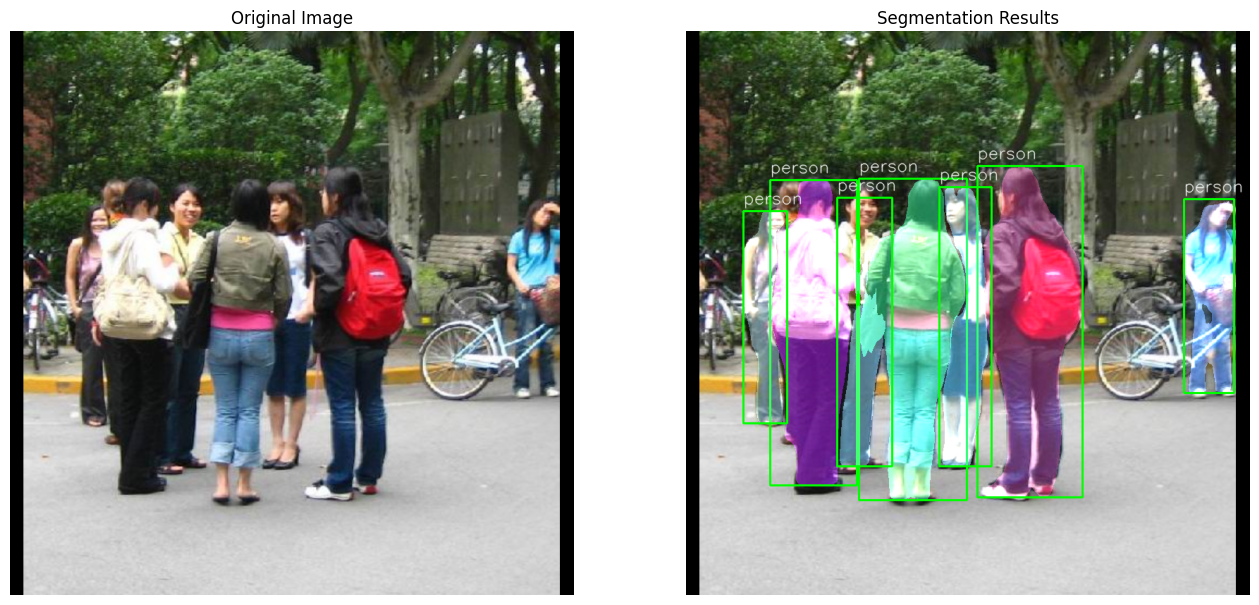

In [7]:
# ==================
# Inference and viz
# ==================
# Set the model to evaluation mode
model.eval()

# Utility to visualize masks and boxes with class labels
def visualize(image_tensor, pred, score_thresh=0.5):
    # Convert image tensor to numpy array and scale to 0-255
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = (image * 255).astype(np.uint8).copy()

    # Extract boxes, scores, masks, and labels from the prediction dictionary
    boxes = pred[0]["boxes"].detach().cpu().numpy()
    scores = pred[0]["scores"].detach().cpu().numpy()
    masks = pred[0]["masks"].detach().cpu().numpy()  # N,1,H,W
    labels = pred[0]["labels"].detach().cpu().numpy() # Predicted labels

    # Keep predictions with score above the threshold
    keep = scores >= score_thresh
    boxes = boxes[keep]
    masks = masks[keep]
    labels = labels[keep] # Keep corresponding labels

    # Define class names (assuming 1 is 'person', 0 is 'background')
    class_names = {1: 'person'}

    overlay = image.copy()
    # Iterate over the kept predictions
    for i in range(len(boxes)):
        # Get bounding box coordinates
        x1, y1, x2, y2 = boxes[i].astype(int)
        # Get the mask for the current object
        mask = masks[i, 0]
        # Create a binary mask
        mask_bin = (mask > 0.5).astype(np.uint8)

        # Generate a random color for the mask
        color = np.random.RandomState(i).randint(0, 255, size=3).tolist()
        colored = np.zeros_like(image)
        # Apply the color to the binary mask
        for c in range(3):
            colored[:, :, c] = mask_bin * color[c]

        # Blend the colored mask with the original image
        overlay = cv2.addWeighted(overlay, 1.0, colored, 0.5, 0)
        # Draw the bounding box
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Add class label text
        label_text = class_names.get(labels[i], 'unknown') # Get class name from label
        # Increased font size
        cv2.putText(overlay, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 1, cv2.LINE_AA)

    # Display original and segmented images side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Segmentation Results")
    axes[1].axis("off")

    plt.show()


# Pick a random validation image and run inference
if len(val_dataset) > 0:
    random_index = random.randint(0, len(val_dataset) - 1) # Pick a random index
    img, _ = val_dataset[random_index] # Use the random index
    with torch.no_grad():
        pred = model([img.to(device)]) # Perform inference
    visualize(img.cpu(), pred, score_thresh=0.5) # Visualize the results
else:
    print("No validation samples to visualize")